<a href="https://colab.research.google.com/github/ham-codes7/Exploratory-Data-Analysis-/blob/main/Exp6_18_08_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Initial Setup: Importing Libraries and Loading Dataset

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


df = wine_df.copy()

print("First 3 rows of Wine Quality dataset (now 'df'):")
print(df.head(3))
print("\nLast 3 rows of Wine Quality dataset (now 'df'):")
print(df.tail(3))

First 3 rows of Wine Quality dataset (now 'df'):
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5   1  
2      9.8        5   2  

Last 3 rows of Wine Quality dataset (now 'df'):
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
1140            6.2             0.600         0.08             2.0      0.090   
1141            5.9       

In [21]:
wine_df = pd.read_csv('/content/WineQT.csv')

print("First 5 rows of Wine Quality dataset:")
display(wine_df.head())

First 5 rows of Wine Quality dataset:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


## 2. Initial Data Inspection

In [23]:
print("\nData Types:")
print(df.dtypes)

print("\nDescriptive Statistics:")
print(df.describe())

print("\nMissing values (using isnull().sum()):")

print(df.isnull().sum())


Data Types:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object

Descriptive Statistics:
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1143.000000       1143.000000  1143.000000     1143.000000   
mean        8.311111          0.531339     0.268364        2.532152   
std         1.747595          0.179633     0.196686        1.355917   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.392500     0.090000        1.900000   
50%         7.900000          0.520000     0.250000        2.200000   
75%         9.100000          0.640

## 3. Data Cleaning and Preprocessing

In [41]:
# 3.1 Cleaning: Check for missing values and data types

print("Performing initial data type and missing value checks...")

# Check for non-numeric values in typically numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
for col in numeric_cols:
    if not pd.to_numeric(df[col], errors='coerce').notna().all():
        print(f"Warning: Non-numeric values found in column '{col}' that should be numeric. Further cleaning may be required.")

# Check for missing values (NaN) across the entire DataFrame
missing_values_count = df.isnull().sum().sum()

if missing_values_count == 0:
    print("No missing values (NaN) found in the dataset. Data is clean regarding missing entries.")
else:
    print(f"Found {missing_values_count} missing values in the dataset. Imputation or removal may be required.")
    # if df['fixed acidity'].isnull().any():
    #    df['fixed acidity'] = df['fixed acidity'].fillna(df['fixed acidity'].mean())
    #    print("Filled missing 'fixed acidity' values with mean.")

Performing initial data type and missing value checks...
No missing values (NaN) found in the dataset. Data is clean regarding missing entries.


In [42]:
# Cleaning for 'volatile acidity':

print("Confirming 'volatile acidity' column status:")
# As confirmed by previous checks, no missing values or non-numeric entries exist.
print("'volatile acidity' column is clean and suitable for analysis.")
print(df['volatile acidity'].head())

Confirming 'volatile acidity' column status:
'volatile acidity' column is clean and suitable for analysis.
0    0.70
1    0.88
2    0.76
3    0.28
4    0.70
Name: volatile acidity, dtype: float64


In [43]:
# Cleaning for 'citric acid':

print("Confirming 'citric acid' column status:")
# As confirmed by previous checks, no missing values or non-numeric entries exist.
print("'citric acid' column is clean and suitable for analysis.")
print(df['citric acid'].head())

Confirming 'citric acid' column status:
'citric acid' column is clean and suitable for analysis.
0    0.00
1    0.00
2    0.04
3    0.56
4    0.00
Name: citric acid, dtype: float64


## 4. Univariate Analysis

In [27]:
# 4.1 Measure of central tendency for the 'alcohol' column

mean_alcohol = df["alcohol"].mean()
median_alcohol = df["alcohol"].median()
mode_alcohol = df["alcohol"].mode()
print(f"Mean of alcohol: {mean_alcohol:.2f}")
print(f"Median of alcohol: {median_alcohol:.2f}")
print(f"Mode of alcohol: {mode_alcohol.tolist()}")

Mean of alcohol: 10.44
Median of alcohol: 10.20
Mode of alcohol: [9.5]


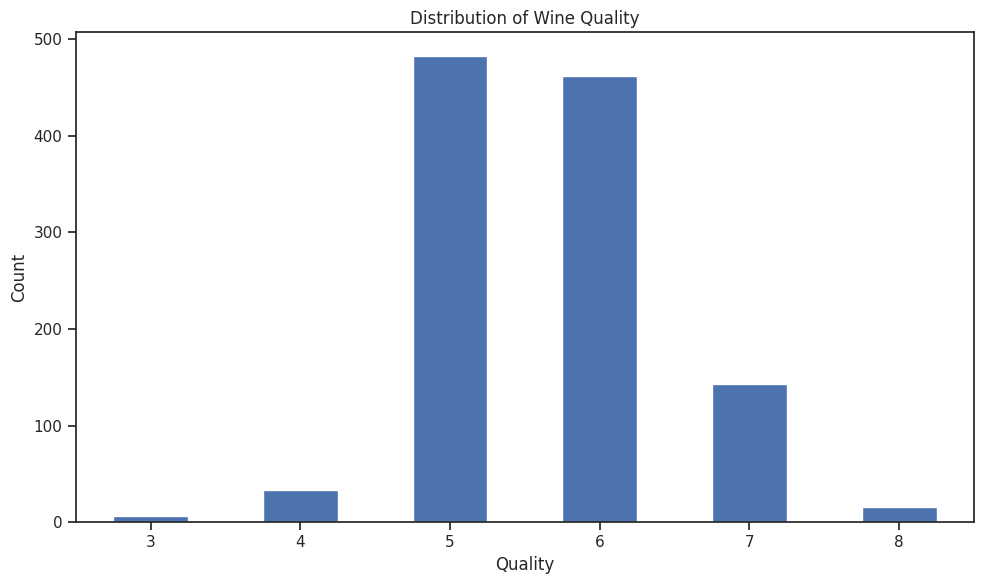

In [28]:
# 4.2 Bar chart of Wine Quality counts

plt.figure(figsize=(10,6))
df.quality.value_counts().sort_index().plot(kind='bar')
plt.title("Distribution of Wine Quality")
plt.ylabel('Count')
plt.xlabel('Quality')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

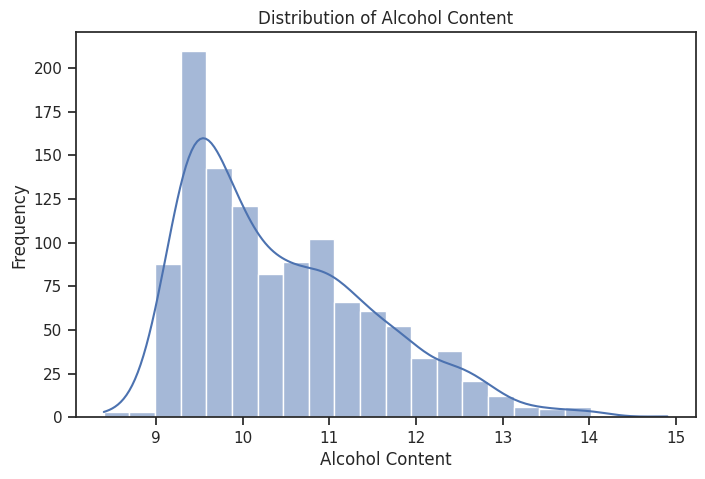

Observation: Most wines have an alcohol content around the central peak observed.


In [29]:
# 4.3 Distribution plot for 'alcohol'

plt.figure(figsize=(8, 5))
sns.histplot(df["alcohol"], kde=True)
plt.title("Distribution of Alcohol Content")
plt.xlabel("Alcohol Content")
plt.ylabel("Frequency")
plt.show()

print("Observation: Most wines have an alcohol content around the central peak observed.")

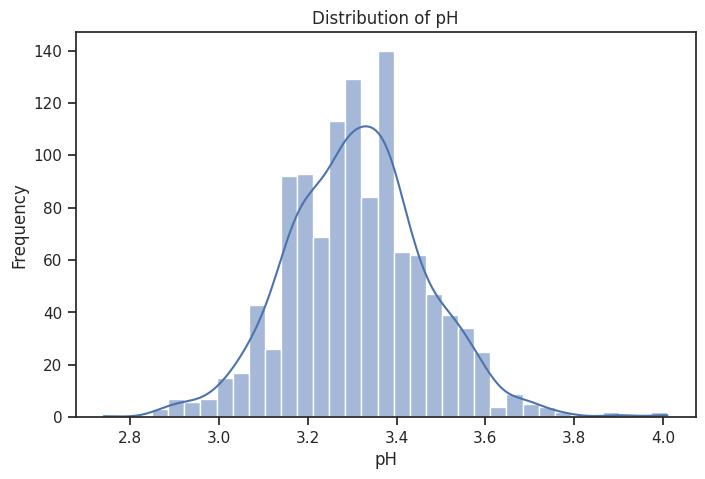

Observation: The pH values tend to cluster around a certain range, indicating typical acidity levels for these wines.


In [30]:
# 4.4 Distribution plot for 'pH'

plt.figure(figsize=(8, 5))
sns.histplot(df["pH"], kde=True)
plt.title("Distribution of pH")
plt.xlabel("pH")
plt.ylabel("Frequency")
plt.show()

print("Observation: The pH values tend to cluster around a certain range, indicating typical acidity levels for these wines.")

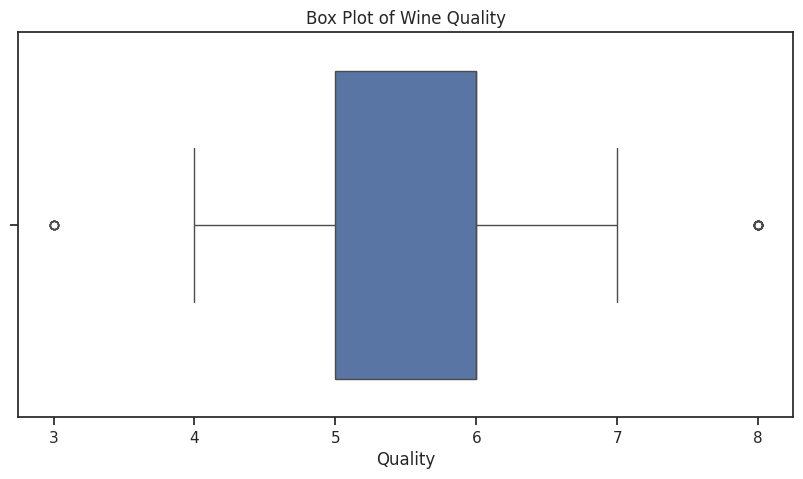

Observation: This box plot shows the distribution of quality ratings. The central box contains the middle 50% of the data, and the line inside is the median. Outliers are marked as individual points.


In [31]:
# 4.5 Box plot for 'quality'

plt.figure(figsize=(10, 5))
sns.boxplot(x="quality",data=df)
plt.title("Box Plot of Wine Quality")
plt.xlabel("Quality")
plt.show()

print("Observation: This box plot shows the distribution of quality ratings. The central box contains the middle 50% of the data, and the line inside is the median. Outliers are marked as individual points.")

## 5. Bivariate Analysis


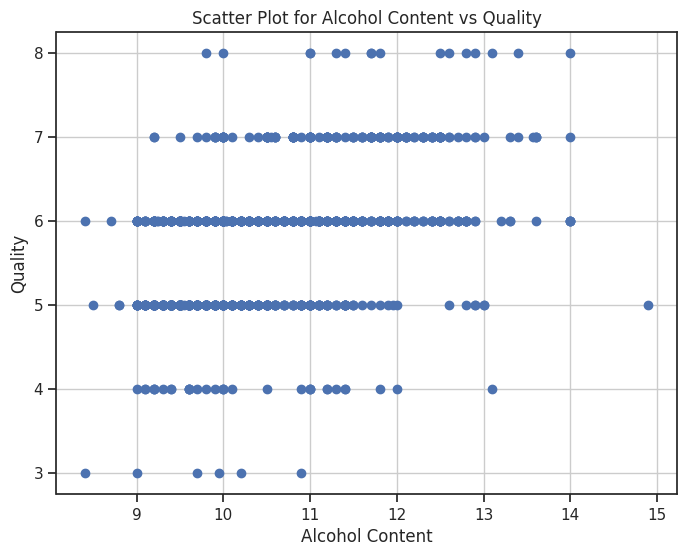

In [32]:
# 5.1 Scatter plot: 'alcohol' vs 'quality'

plt.figure(figsize=(8, 6))
plt.scatter(df["alcohol"], df["quality"])
plt.title("Scatter Plot for Alcohol Content vs Quality")
plt.xlabel("Alcohol Content")
plt.ylabel("Quality")
plt.grid(True)
plt.show()

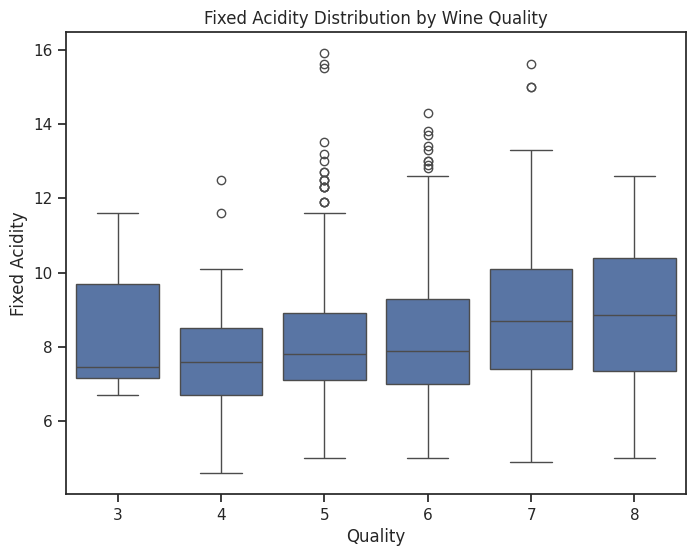

In [33]:
# 5.2 Box plot: 'quality' vs 'fixed acidity' (using quality as a categorical grouping)

plt.figure(figsize=(8, 6))
sns.boxplot(x="quality", y="fixed acidity", data=df)
plt.title("Fixed Acidity Distribution by Wine Quality")
plt.xlabel("Quality")
plt.ylabel("Fixed Acidity")
plt.show()

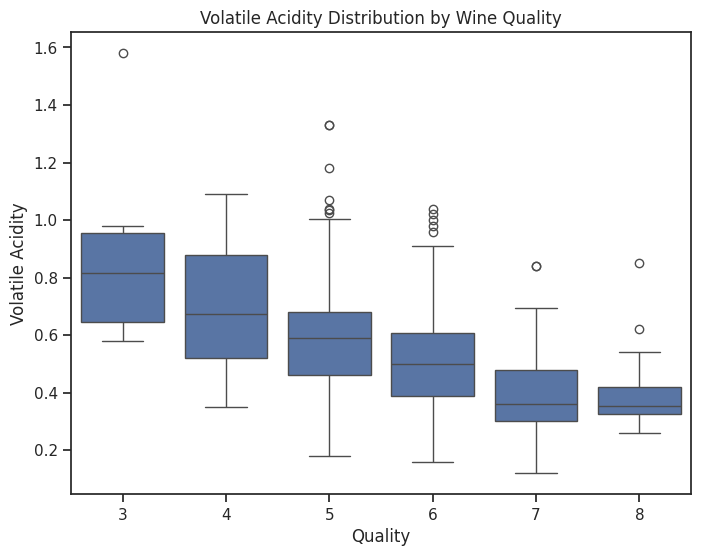

Observation: These diagrams show the range of volatile acidity for different quality ratings, including average, median, and potential outliers.


In [34]:
# 5.3 Box plot: 'quality' vs 'volatile acidity' (using quality as a categorical grouping)

plt.figure(figsize=(8, 6))
sns.boxplot(x="quality", y="volatile acidity", data=df)
plt.title("Volatile Acidity Distribution by Wine Quality")
plt.xlabel("Quality")
plt.ylabel("Volatile Acidity")
plt.show()

print("Observation: These diagrams show the range of volatile acidity for different quality ratings, including average, median, and potential outliers.")

## 6. Multivariate Analysis


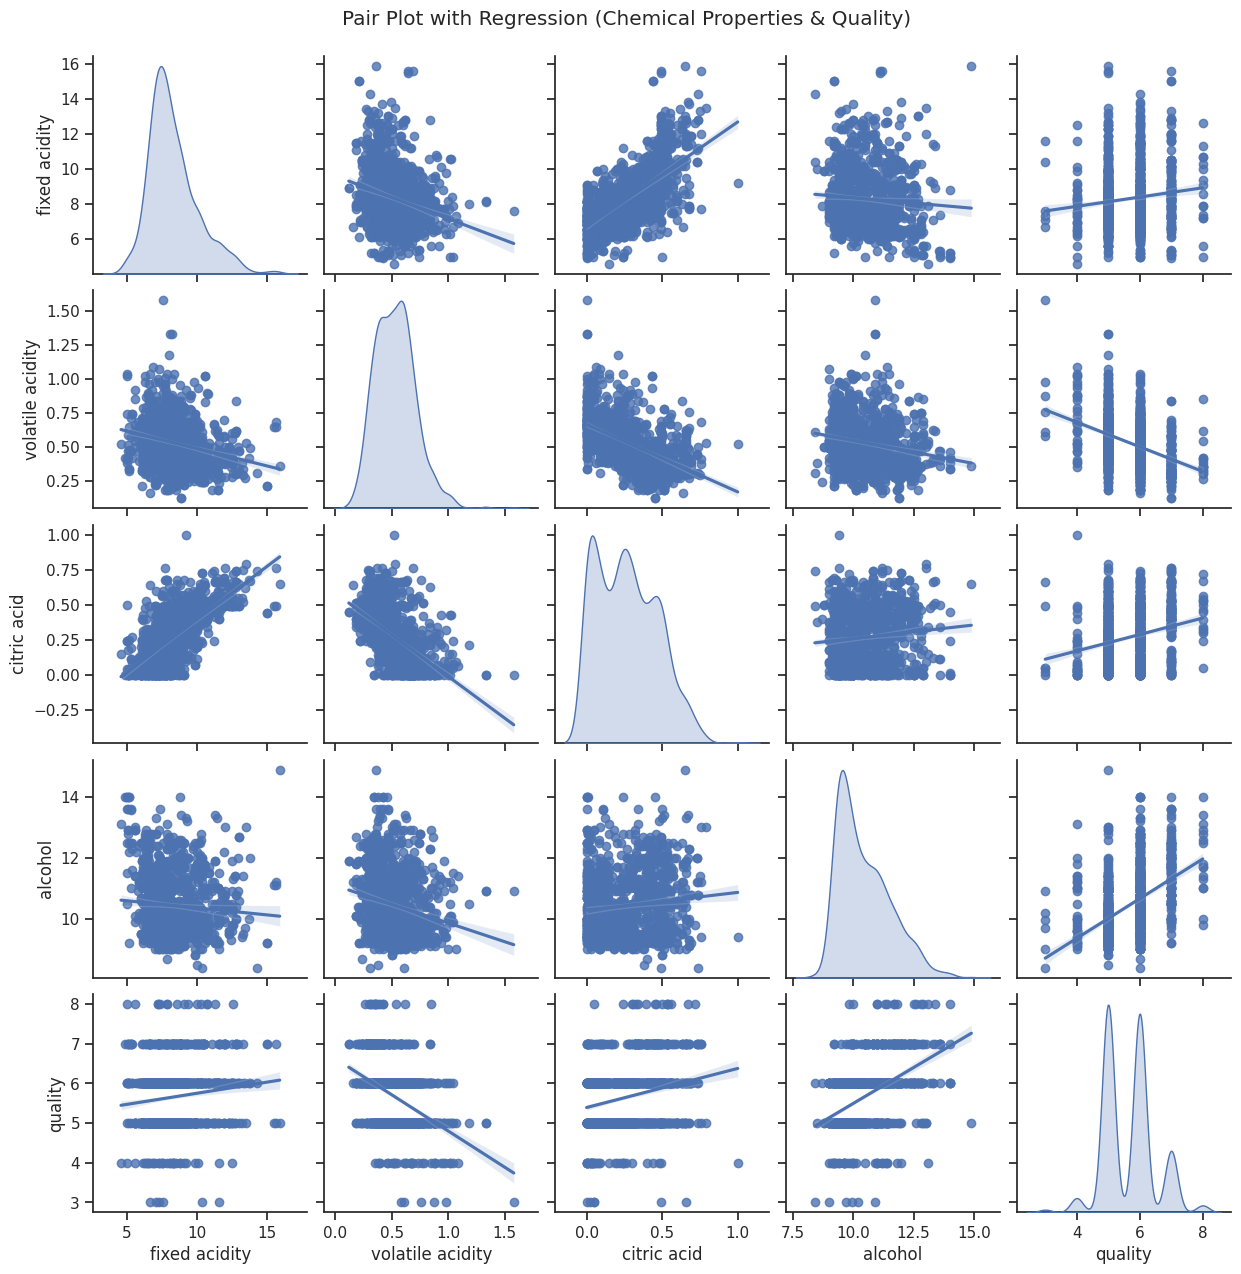

Observation: The histograms on the diagonal illustrate the distribution of single variables.
The regression plots show relationships between pairs of variables. Look for upward or downward slopes to infer correlations.


In [35]:
# 6.1 Pair plot with regression for key chemical properties and quality

sns.pairplot(df, vars = ['fixed acidity', 'volatile acidity', 'citric acid', 'alcohol', 'quality'], kind="reg", diag_kind="kde")
plt.suptitle("Pair Plot with Regression (Chemical Properties & Quality)", y=1.02) # Adjust title position
plt.show()

print("Observation: The histograms on the diagonal illustrate the distribution of single variables.")
print("The regression plots show relationships between pairs of variables. Look for upward or downward slopes to infer correlations.")

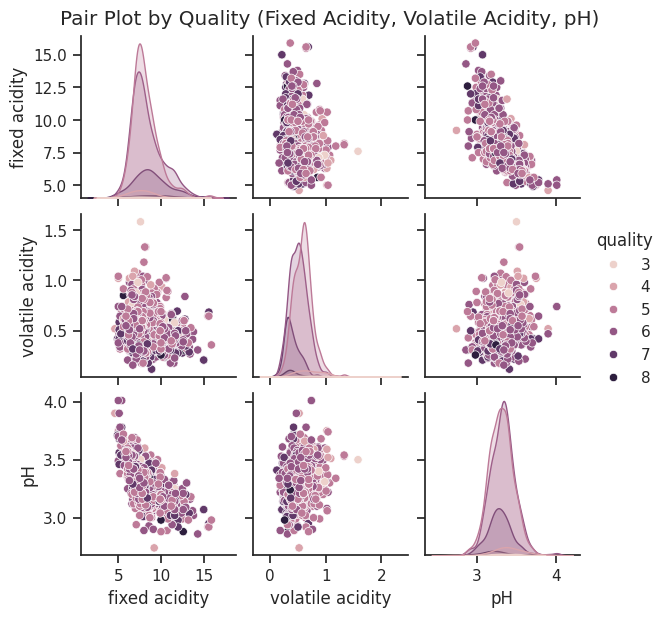

Observation: The density plots on the diagonal show the distribution of a single variable, separated by wine quality.
The scatter plots on the upper and lower triangles show the relationship between two variables, with colors indicating different quality ratings.
The 'hue' parameter helps in identifying if different quality levels exhibit distinct patterns in these chemical properties.


In [36]:
# 6.2 Pair plot with hue by 'quality'

sns.set(style="ticks", color_codes=True)
sns.pairplot(df, height=2, vars = ['fixed acidity', 'volatile acidity', 'pH'], hue="quality", diag_kind="kde")
plt.suptitle("Pair Plot by Quality (Fixed Acidity, Volatile Acidity, pH)", y=1.02)
plt.show()

print("Observation: The density plots on the diagonal show the distribution of a single variable, separated by wine quality.")
print("The scatter plots on the upper and lower triangles show the relationship between two variables, with colors indicating different quality ratings.")
print("The 'hue' parameter helps in identifying if different quality levels exhibit distinct patterns in these chemical properties.")

## 7. Correlation Analysis

In [37]:
# 7.1 Calculate the Pearson correlation coefficient for 'alcohol' and 'quality'

from scipy import stats

corr, p_value = stats.pearsonr(df["alcohol"], df["quality"])
print(f"Pearson Correlation Coefficient (alcohol vs quality): {corr:.3f}")
print(f"P-value: {p_value:.2e}")

Pearson Correlation Coefficient (alcohol vs quality): 0.485
P-value: 1.92e-68


In [38]:
# 7.2 Compute the correlation matrix for all numerical records

# To find the correlation among the entire numerical records using pearson method
correlation = df.corr(method='pearson', numeric_only=True)
print("\nCorrelation Matrix:")
display(correlation)


Correlation Matrix:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
fixed acidity,1.000000,-0.250728,0.673157,0.171831,0.107889,-0.164831,-0.110628,0.681501,-0.685163,0.174592,-0.075055,0.121970,-0.275826
volatile acidity,-0.250728,1.000000,-0.544187,-0.005751,0.056336,-0.001962,0.077748,0.016512,0.221492,-0.276079,-0.203909,-0.407394,-0.007892
citric acid,0.673157,-0.544187,1.000000,0.175815,0.245312,-0.057589,0.036871,0.375243,-0.546339,0.331232,0.106250,0.240821,-0.139011
residual sugar,0.171831,-0.005751,0.175815,1.000000,0.070863,0.165339,0.190790,0.380147,-0.116959,0.017475,0.058421,0.022002,-0.046344
chlorides,0.107889,0.056336,0.245312,0.070863,1.000000,0.015280,0.048163,0.208901,-0.277759,0.374784,-0.229917,-0.124085,-0.088099
free sulfur dioxide,-0.164831,-0.001962,-0.057589,0.165339,0.015280,1.000000,0.661093,-0.054150,0.072804,0.034445,-0.047095,-0.063260,0.095268
total sulfur dioxide,-0.110628,0.077748,0.036871,0.190790,0.048163,0.661093,1.000000,0.050175,-0.059126,0.026894,-0.188165,-0.183339,-0.107389
density,0.681501,0.016512,0.375243,0.380147,0.208901,-0.054150,0.050175,1.000000,-0.352775,0.143139,-0.494727,-0.175208,-0.363926
pH,-0.685163,0.221492,-0.546339,-0.116959,-0.277759,0.072804,-0.059126,-0.352775,1.000000,-0.185499,0.225322,-0.052453,0.132904
sulphates,0.174592,-0.276079,0.331232,0.017475,0.374784,0.034445,0.026894,0.143139,-0.185499,1.000000,0.094421,0.257710,-0.103954


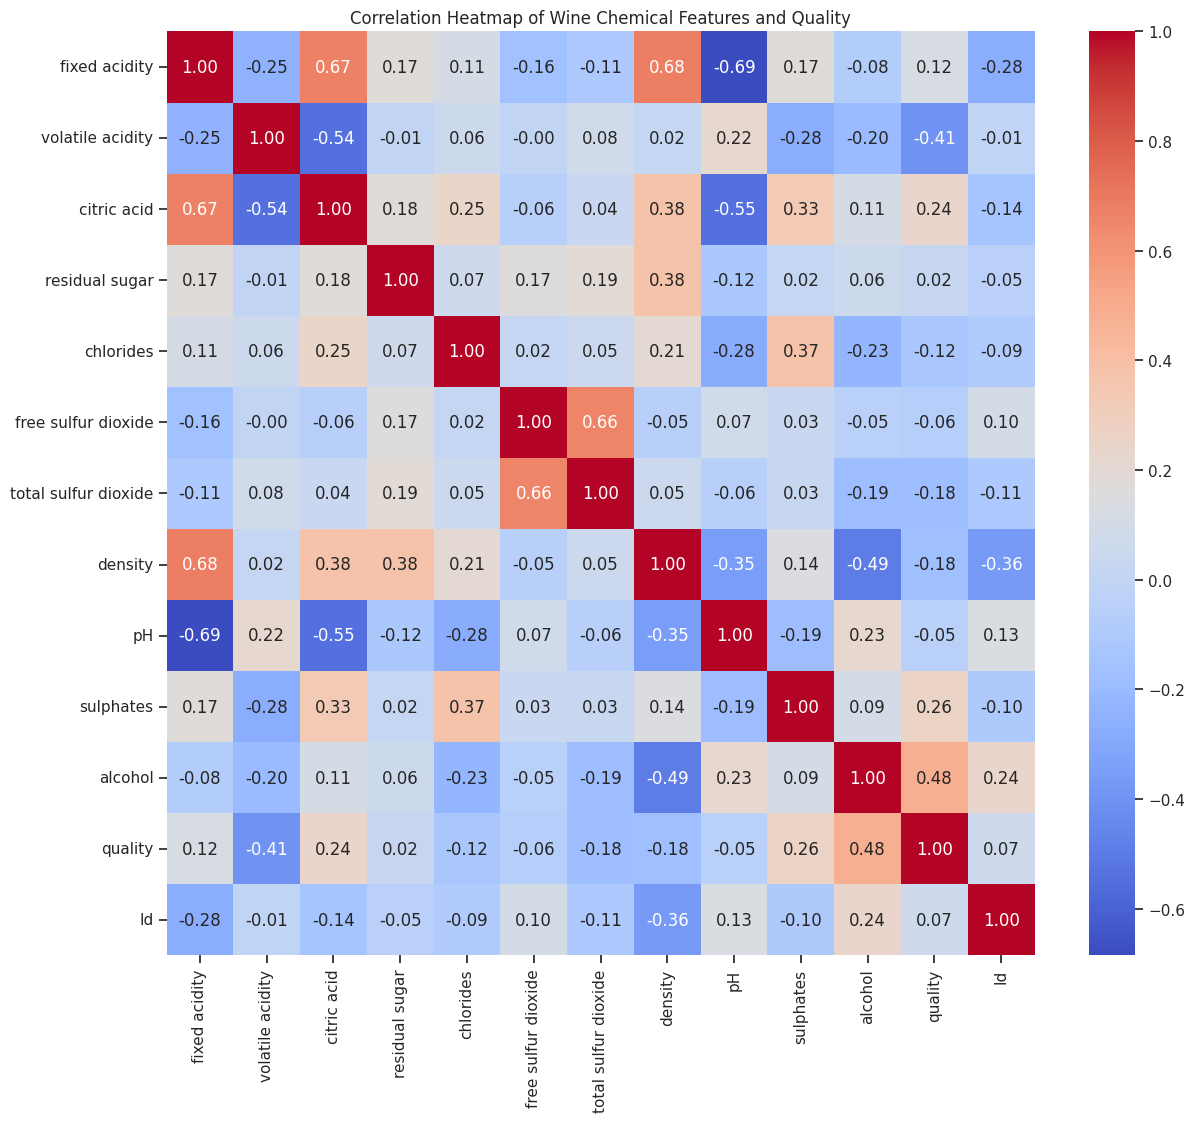

Observation: A coefficient close to 1 or -1 means a very strong positive or negative correlation, respectively.
The diagonal line shows variables correlated to themselves, which is always 1.
The heatmap visually represents the strength and direction of relationships between all numerical pairs in the wine dataset.


In [39]:
# 7.3 Visualize the correlation analysis using a heatmap

plt.figure(figsize=(14, 12)) # Adjusted figure size for more columns
sns.heatmap(correlation, xticklabels=correlation.columns,
            yticklabels=correlation.columns, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Wine Chemical Features and Quality")
plt.show()

print("Observation: A coefficient close to 1 or -1 means a very strong positive or negative correlation, respectively.")
print("The diagonal line shows variables correlated to themselves, which is always 1.")
print("The heatmap visually represents the strength and direction of relationships between all numerical pairs in the wine dataset.")